# BMW Global Sales Analysis and Forecasting (2018–2025)

This project analyzes BMW global sales data to identify sales trends,
market performance, and economic factors affecting car sales.
We also build machine learning models to predict future sales."

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
df = pd.read_csv("C:/Users/gowth/DataSet/data_set_19/data/bmw_global_sales_2018_2025.csv")
df.head(35)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
5,2018,1,Europe,i4,10607,64082,679717774,0.035,19.12,3.50,1.00
6,2018,1,Europe,iX,4805,73975,355449875,0.016,19.12,3.50,1.00
7,2018,1,Europe,MINI,2554,43005,109834770,0.013,19.12,3.50,1.00
8,2018,1,China,3 Series,3826,48068,183908168,0.021,17.60,2.37,1.02
9,2018,1,China,5 Series,7498,62435,468137630,0.015,17.60,2.37,1.02


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [9]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [22]:
df[['Units_Sold','Avg_Price_EUR','Revenue_EUR']].describe()

,Units_Sold,Avg_Price_EUR,Revenue_EUR
count,3072.000000,3072.000000,3.072000e+03
mean,7980.288086,63854.561523,5.113995e+08
std,3174.917444,14655.891299,2.431185e+08
min,2379.000000,40011.000000,1.045314e+08
25%,5225.500000,54500.250000,3.125504e+08
50%,7985.500000,63493.000000,4.808690e+08
75%,10528.250000,71489.500000,6.709141e+08
max,15914.000000,93994.000000,1.433482e+09


In [12]:
df.sample(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
1216,2021,3,Europe,3 Series,6201,46660,289338660,0.095,14.82,1.79,1.14
2212,2023,10,Europe,X7,6446,92676,597389496,0.159,17.64,2.84,1.31
1745,2022,7,USA,5 Series,3711,61105,226760655,0.133,20.77,0.10,1.22
1298,2021,5,USA,X3,9197,57311,527089267,0.091,15.82,3.53,1.12
89,2018,3,RestOfWorld,5 Series,10070,60399,608217930,0.025,6.73,3.52,1.02


In [14]:
#missing values
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [15]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

In [18]:
#unique values and value counts
df['Region'].unique()
df['Region'].value_counts()


Region
Europe         768
China          768
USA            768
RestOfWorld    768
Name: count, dtype: int64

In [19]:
df['Model'].unique()
df['Model'].value_counts()

Model
3 Series    384
5 Series    384
X3          384
X5          384
X7          384
i4          384
iX          384
MINI        384
Name: count, dtype: int64

In [25]:
#revenue validation

df["Calculated_Revenue"] = df["Units_Sold"] * df["Avg_Price_EUR"]

difference = df["Revenue_EUR"] - df["Calculated_Revenue"]

print(difference.mean())

0.0


In [26]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,371404204
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,634121800
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,181434465
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,504226100
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,782150200


In [30]:
#date feature
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)
df = df.sort_values("Date")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01
24,2018,1,RestOfWorld,3 Series,10121,47485,480595685,-0.000,6.28,4.18,0.97,480595685,2018-01-01
18,2018,1,USA,X3,7017,56379,395611443,0.007,20.49,0.82,0.97,395611443,2018-01-01
19,2018,1,USA,X5,10624,70112,744869888,0.011,20.49,0.82,0.97,744869888,2018-01-01
20,2018,1,USA,X7,7387,91698,677373126,0.026,20.49,0.82,0.97,677373126,2018-01-01


# Exploraotory Data Analysis

In [31]:
#Global sales Trend

sales_trend = df.groupby("Date")["Units_Sold"].sum().reset_index()

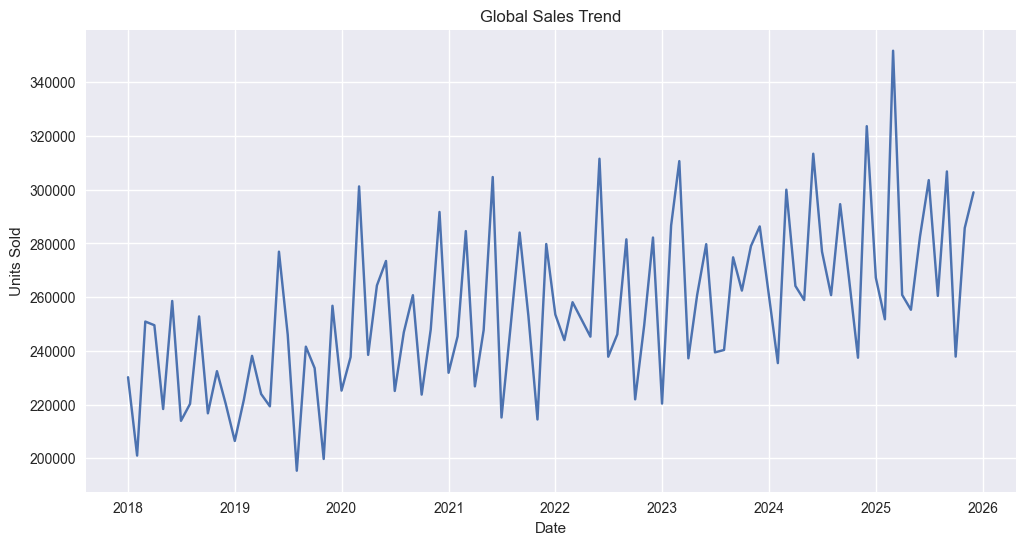

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_trend, x="Date", y="Units_Sold")

plt.title("Global Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [33]:
#Revenue Trend
revenue_trend = df.groupby("Date")["Revenue_EUR"].sum().reset_index()


In [38]:
revenue_trend["Revenue_Billion"] = revenue_trend["Revenue_EUR"] / 1e9

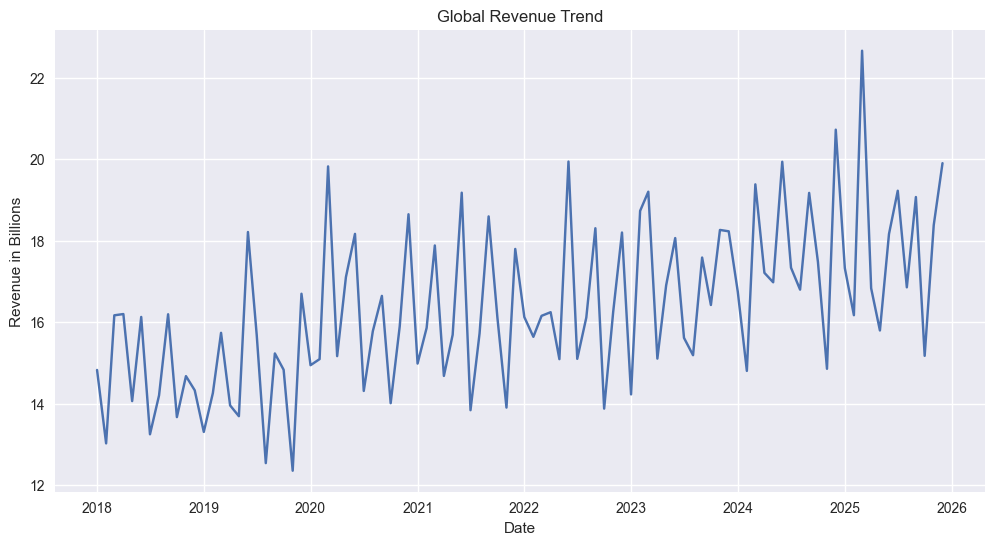

In [41]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=revenue_trend, x="Date", y="Revenue_Billion")

plt.title("Global Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue in Billions")
plt.show()

In [42]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index', 'Calculated_Revenue', 'Date'],
      dtype='object')

In [ ]:
df.des

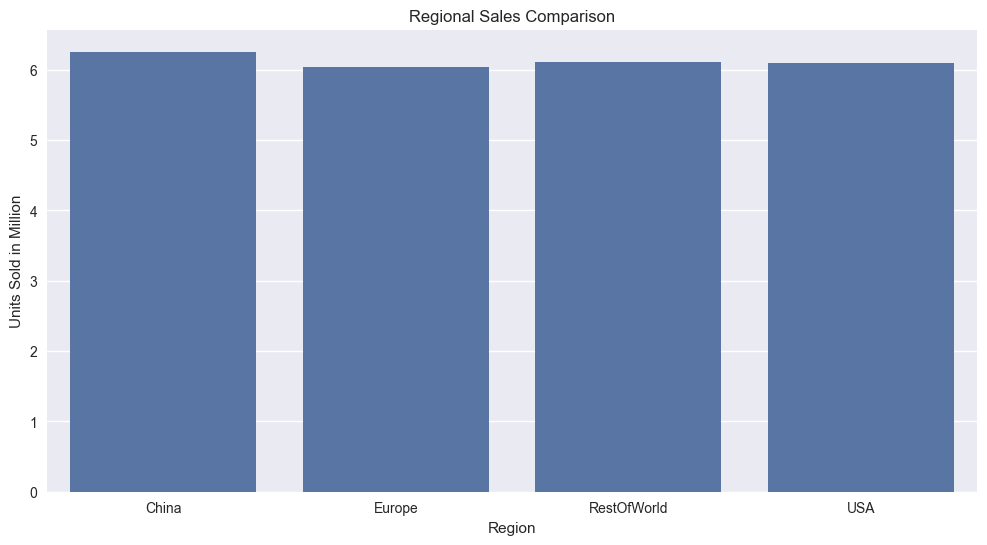

In [ ]:
#Sales by regions
regional_sales = df.groupby("Region")["Units_Sold"].sum().reset_index()
regional_sales["Units_Million"] = regional_sales["Units_Sold"] / 1e6

plt.figure(figsize=(12, 6))

sns.barplot(data=regional_sales, x="Region", y="Units_Million")

plt.title("Regional Sales Comparison")
plt.xlabel("Region")
plt.ylabel("Units Sold in Million")
plt.show()

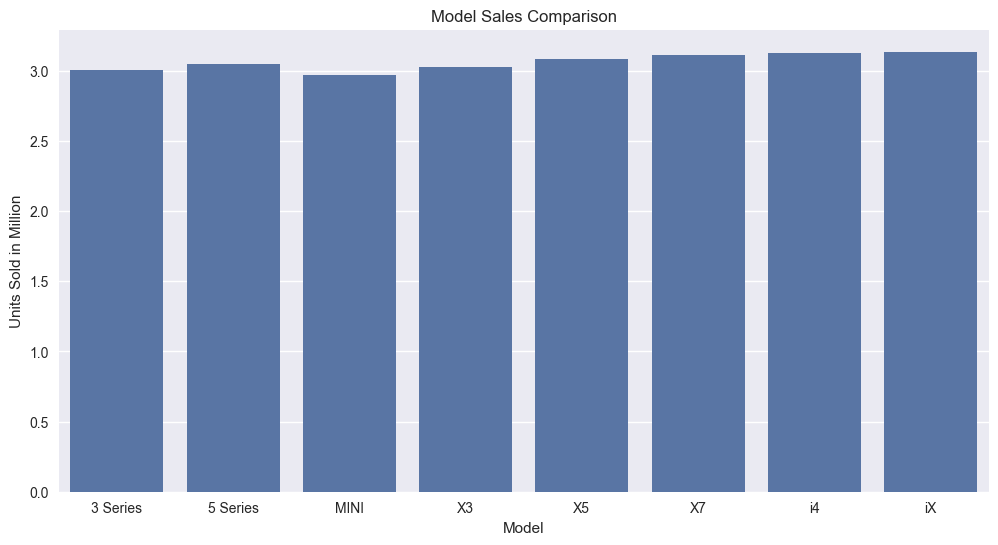

In [46]:
#sales by model
model_sales = df.groupby("Model")["Units_Sold"].sum().reset_index()
model_sales["Units_Million"] = model_sales["Units_Sold"] / 1e6

plt.figure(figsize=(12, 6))

sns.barplot(data=model_sales, x="Model", y="Units_Million")

plt.title("Model Sales Comparison")
plt.xlabel("Model")
plt.ylabel("Units Sold in Million")
plt.show()

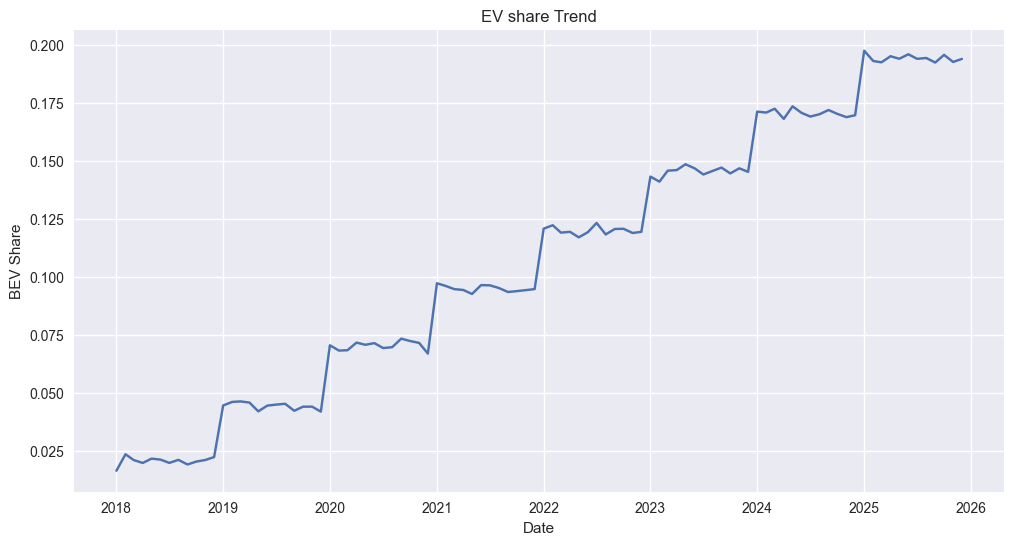

In [48]:
#Ev adoption trend
ev_trend = df.groupby("Date")["BEV_Share"].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=ev_trend, x="Date", y="BEV_Share")

plt.title("EV share Trend")
plt.xlabel("Date")
plt.ylabel("BEV Share")
plt.show()

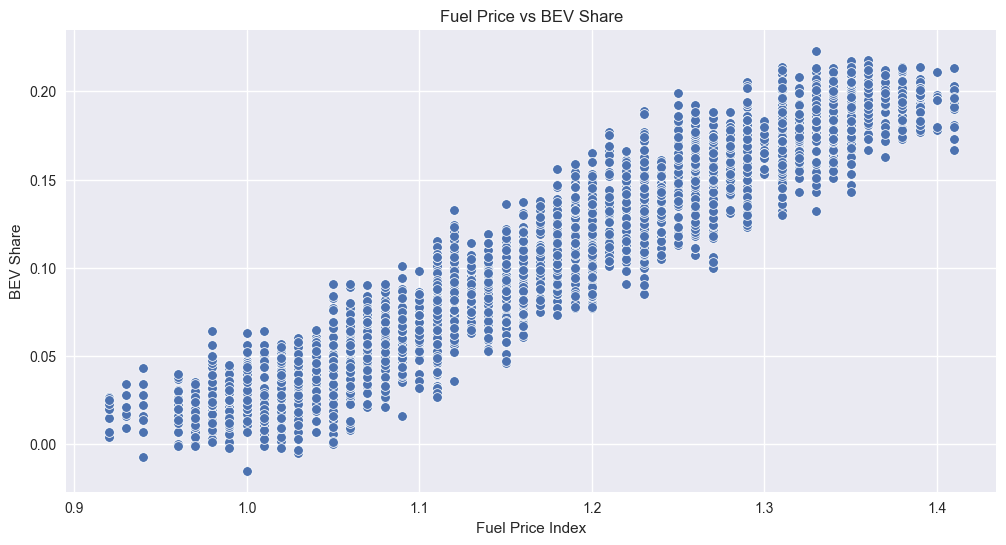

In [49]:
#fuel price vs Ev share

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x="Fuel_Price_Index", y="BEV_Share")

plt.title("Fuel Price vs BEV Share")
plt.xlabel("Fuel Price Index")
plt.ylabel("BEV Share")
plt.show()

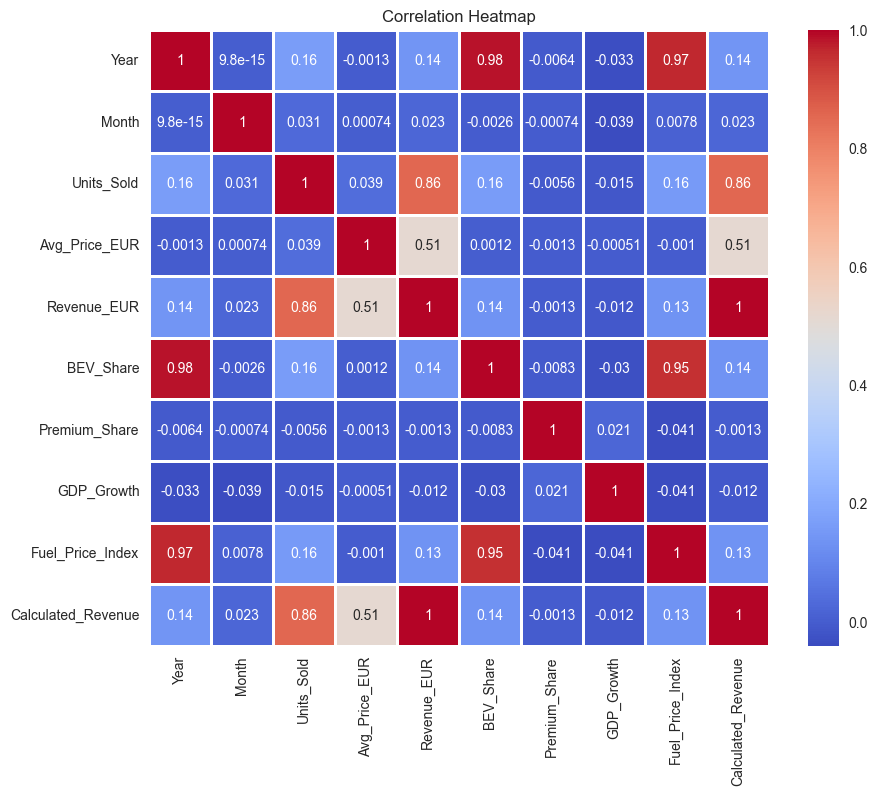

In [50]:
#correlation heatmap
num_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", linewidths=1)
plt.title("Correlation Heatmap")
plt.show()


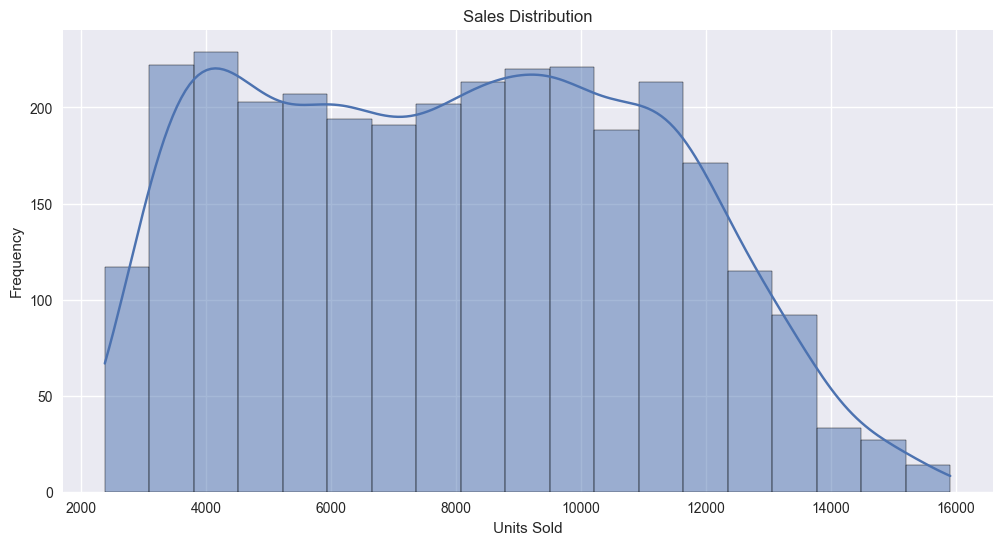

In [51]:
#sales distribution

plt.figure(figsize=(12, 6))

sns.histplot(data=df, x="Units_Sold", kde=True)

plt.title("Sales Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

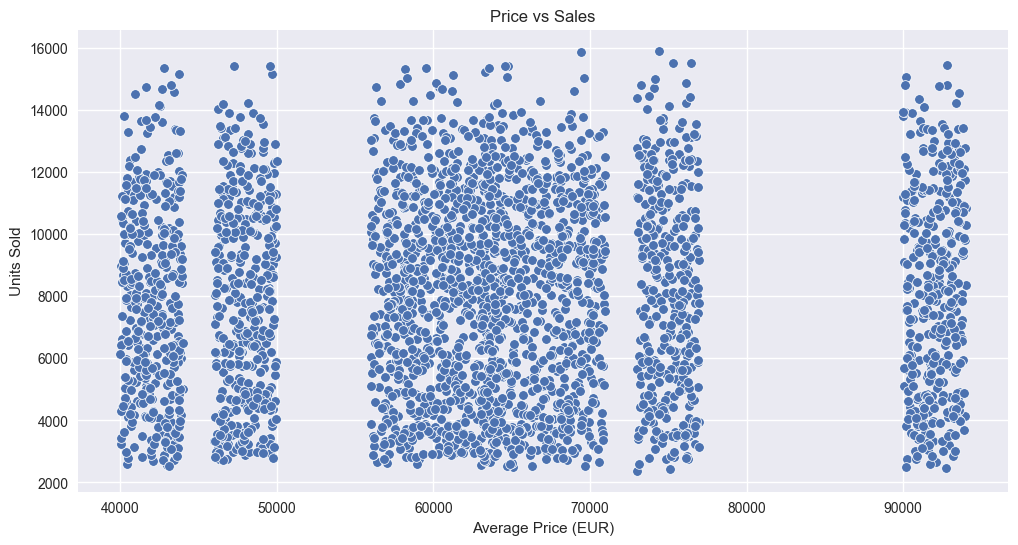

In [52]:
#price vs sales

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x="Avg_Price_EUR", y="Units_Sold")

plt.title("Price vs Sales")
plt.xlabel("Average Price (EUR)")
plt.ylabel("Units Sold")
plt.show()

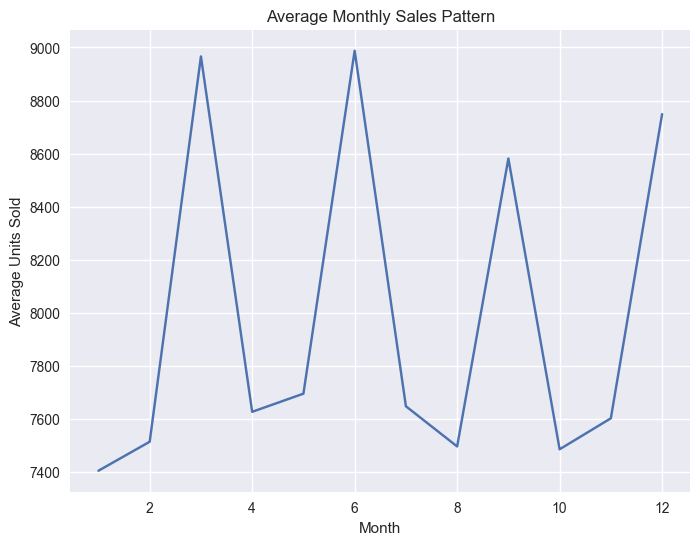

In [53]:
#monthly sales pattern

monthly_sales = df.groupby("Month")["Units_Sold"].mean()

plt.figure(figsize=(8,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Average Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.show()

# Feature Engineering

In [57]:
df["Quarter"] = df["Date"].dt.quarter
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1
24,2018,1,RestOfWorld,3 Series,10121,47485,480595685,-0.000,6.28,4.18,0.97,480595685,2018-01-01,1
18,2018,1,USA,X3,7017,56379,395611443,0.007,20.49,0.82,0.97,395611443,2018-01-01,1
19,2018,1,USA,X5,10624,70112,744869888,0.011,20.49,0.82,0.97,744869888,2018-01-01,1
20,2018,1,USA,X7,7387,91698,677373126,0.026,20.49,0.82,0.97,677373126,2018-01-01,1


In [58]:
#Revenue Per Unit
df["Revenue_per_unit"] = df["Revenue_EUR"] / df["Units_Sold"]
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter,Revenue_per_unit
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1,47482.0
24,2018,1,RestOfWorld,3 Series,10121,47485,480595685,-0.000,6.28,4.18,0.97,480595685,2018-01-01,1,47485.0
18,2018,1,USA,X3,7017,56379,395611443,0.007,20.49,0.82,0.97,395611443,2018-01-01,1,56379.0
19,2018,1,USA,X5,10624,70112,744869888,0.011,20.49,0.82,0.97,744869888,2018-01-01,1,70112.0
20,2018,1,USA,X7,7387,91698,677373126,0.026,20.49,0.82,0.97,677373126,2018-01-01,1,91698.0


In [59]:
#Lag features

df = df.sort_values("Date")

df["Sales_Lag_1"] = df["Units_Sold"].shift(1)
df["Sales_Lag_3"] = df["Units_Sold"].shift(3)
df["Sales_Lag_6"] = df["Units_Sold"].shift(6)

df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter,Revenue_per_unit,Sales_Lag_1,Sales_Lag_3,Sales_Lag_6
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1,47482.0,NaN,NaN,NaN
7,2018,1,Europe,MINI,2554,43005,109834770,0.013,19.12,3.50,1.00,109834770,2018-01-01,1,43005.0,7822.0,NaN,NaN
15,2018,1,China,MINI,6025,43893,264455325,0.031,17.60,2.37,1.02,264455325,2018-01-01,1,43893.0,2554.0,NaN,NaN
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00,634121800,2018-01-01,1,61685.0,6025.0,7822.0,NaN
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00,181434465,2018-01-01,1,58433.0,10280.0,2554.0,NaN


In [64]:
#Rolling sales average

df["Sales_Rolling_3"] = df["Units_Sold"].rolling(3).mean()
df["Sales_Rolling_6"] = df["Units_Sold"].rolling(6).mean()
df[['Sales_Rolling_3', "Sales_Rolling_6"]]

,Sales_Rolling_3,Sales_Rolling_6
0,NaN,NaN
7,NaN,NaN
15,5467.000000,NaN
1,6286.333333,NaN
2,6470.000000,NaN
...,...,...
3056,10712.000000,9152.166667
3064,9107.666667,7920.000000
3048,6788.333333,8073.500000
3065,5253.666667,7982.833333


In [65]:
#Sales Growth rate

df["Sales_Growth"] = df["Units_Sold"].pct_change()
df["Sales_Growth"]

0            NaN
7      -0.673485
15      1.359045
1       0.706224
2      -0.697957
          ...   
3056   -0.212358
3064   -0.556306
3048    0.304163
3065   -0.061953
3071    0.231614
Name: Sales_Growth, Length: 3072, dtype: float64

In [66]:
#Ev demand indicator

df["EV_Demand_Index"] = df["BEV_Share"] * df["Fuel_Price_Index"]
df["EV_Demand_Index"]

0       0.01100
7       0.01300
15      0.03162
1       0.01900
2       0.02200
         ...   
3056    0.28832
3064    0.24393
3048    0.24339
3065    0.27777
3071    0.23547
Name: EV_Demand_Index, Length: 3072, dtype: float64

In [67]:
df = df.dropna()

df.shape

(3066, 22)

In [68]:
df.isnull().sum()

Year                  0
Month                 0
Region                0
Model                 0
Units_Sold            0
Avg_Price_EUR         0
Revenue_EUR           0
BEV_Share             0
Premium_Share         0
GDP_Growth            0
Fuel_Price_Index      0
Calculated_Revenue    0
Date                  0
Quarter               0
Revenue_per_unit      0
Sales_Lag_1           0
Sales_Lag_3           0
Sales_Lag_6           0
Sales_Rolling_3       0
Sales_Rolling_6       0
Sales_Growth          0
EV_Demand_Index       0
dtype: int64

In [69]:
df.to_csv("cleaned_bmw_sales_data.csv", index=False)